In [15]:
import numpy as np
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics.pairwise import euclidean_distances
from tensorflow.keras.datasets import mnist
import os
from PIL import Image
import random


# Uploading MNIST

In [17]:
# Step 2: Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Select only the first 1000 images
x_train = x_train[:20000]
y_train = y_train[:20000]

# Flatten images from 28x28 to 784
x_train_flat = x_train.reshape((x_train.shape[0], -1)).astype(np.float32)
x_test_flat = x_test.reshape((x_test.shape[0], -1)).astype(np.float32)

# Normalize the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

# Apply PCA with 40 components
pca = PCA(n_components=40)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

## Importing UMAP Code

c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP(min_dist=0.25, verbose=True)
Mon Jul 21 15:23:02 2025 Construct fuzzy simplicial set
Mon Jul 21 15:23:02 2025 Finding Nearest Neighbors
Mon Jul 21 15:23:02 2025 Building RP forest with 12 trees
Mon Jul 21 15:23:07 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Mon Jul 21 15:23:18 2025 Finished Nearest Neighbor Search
Mon Jul 21 15:23:20 2025 Construct embedding


Epochs completed:  13%| █▎         26/200 [00:01]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs


Epochs completed:  43%| ████▎      86/200 [00:01]

	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs


Epochs completed:  74%| ███████▎   147/200 [00:02]

	completed  120  /  200 epochs
	completed  140  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:02]

	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Jul 21 15:23:24 2025 Finished embedding


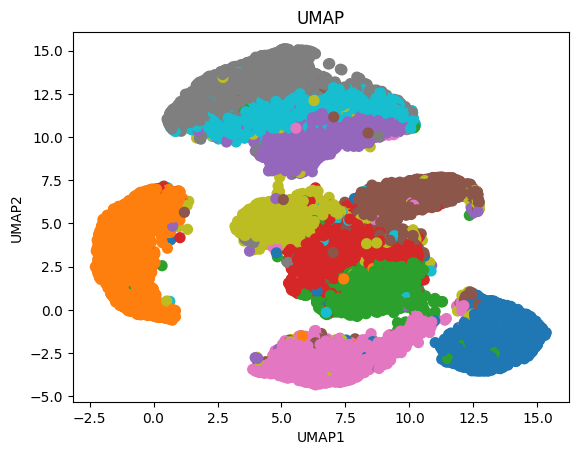

In [3]:
# to run this you need a folder with specific UMAP functions uploaded into it, that is where I alter their code for our purposes
from UMAP.umap_ import UMAP

model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(x_train_pca)
plt.scatter(umap[:, 0], umap[:, 1], c = y_train.astype(int), cmap = 'tab10', s = 50)
plt.title('UMAP')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

## Custom UMAP

In [ ]:
from UMAP.umap_custom import UMAP

model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(x_train_pca)
plt.scatter(umap[:, 0], umap[:, 1], c = y_train.astype(int), cmap = 'tab10', s = 50)
plt.title('UMAP p_ij = q_ij')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

UMAP(min_dist=0.25, verbose=True)
Mon Jul 21 15:20:47 2025 Construct embedding


UMAP(min_dist=0.25, verbose=True)
Wed Jun 25 06:53:56 2025 Construct embedding


c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\umap\spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\umap\spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\umap\spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:00]


Wed Jun 25 06:53:57 2025 Finished embedding


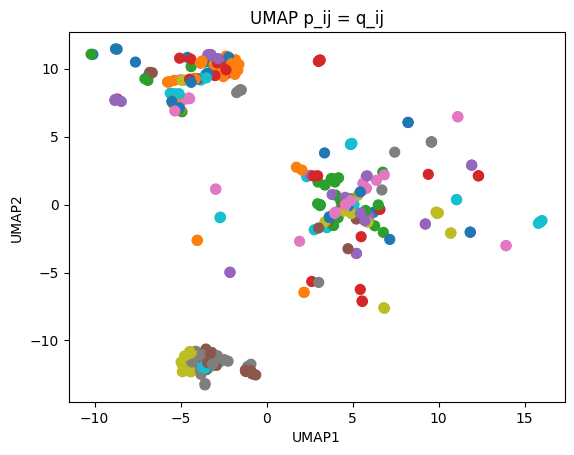

In [ ]:
from UMAP.umap_custom import UMAP

model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(X_pca_face)
plt.scatter(umap[:, 0], umap[:, 1], c = y_f.astype(int), cmap = 'tab10', s = 50)
plt.title('UMAP p_ij = q_ij')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

UMAP(min_dist=0.25, verbose=True)
Wed Jun 25 06:54:30 2025 Construct embedding


c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\umap\spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
Epochs completed:   8%| ▊          39/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs


Epochs completed:  35%| ███▍       173/500 [00:00]

	completed  100  /  500 epochs
	completed  150  /  500 epochs


...

	completed  300  /  500 epochs
	completed  350  /  500 epochs


Epochs completed:  93%| █████████▎ 465/500 [00:01]

	completed  400  /  500 epochs
	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:01]


Wed Jun 25 06:54:31 2025 Finished embedding


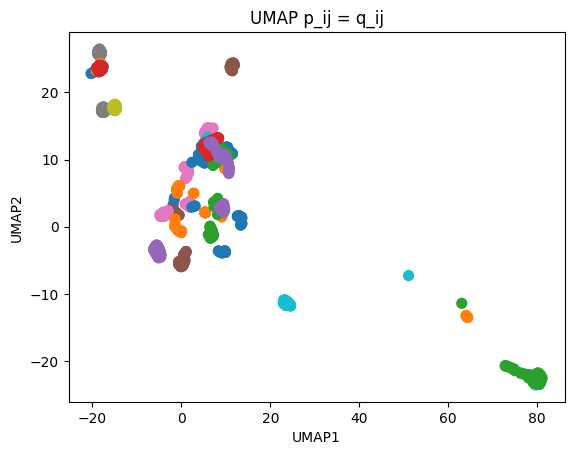

In [ ]:
from UMAP.umap_custom import UMAP

model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(X_pca_coil)
plt.scatter(umap[:, 0], umap[:, 1], c = y_c.astype(int), cmap = 'tab10', s = 50)
plt.title('UMAP p_ij = q_ij')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

# Additional Datasets

## Olivetti Faces

In [17]:
from sklearn.datasets import fetch_olivetti_faces

# Load data
faces = fetch_olivetti_faces(shuffle=True, random_state=1)
X = faces.data
y_f = faces.target

# Take first 1500 samples for simplicity
X = X[:1500]
y_f = y_f[:1500]

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 40 components
pca = PCA(n_components=40)
X_pca_face = pca.fit_transform(X_scaled)

## COIL-20


In [16]:
path = r'C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\coil-20-proc\coil-20-proc'
X = []
y_c = []

for file in sorted(os.listdir(path)):
    if file.endswith(".png"):
        label = int(file.split("_")[0].replace("obj", ""))
        img = Image.open(os.path.join(path, file)).convert("L").resize((32, 32))  # resize if needed
        X.append(np.array(img).flatten())
        y_c.append(label)

X = np.array(X)
y_c = np.array(y_c)

# Scale and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=40)
X_pca_coil = pca.fit_transform(X_scaled)

In [31]:
import scanpy as sc

# Path to your file
adata = sc.read(r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\all_neurons.h5ad", backed="r")

# Take the first 1500 samples
adata = adata[:2500].to_memory()

# Skip if already normalized — check adata.raw or metadata to decide
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Keep only highly variable genes to reduce dimensionality
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')

X_pca_brain = adata.obsm["X_pca"]
y_b = adata.obs["subcluster_id"].astype("category").cat.codes

c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


# UMAP on additional sets

UMAP(min_dist=0.25, verbose=True)
Tue Jun 24 17:11:03 2025 Construct fuzzy simplicial set
Tue Jun 24 17:11:03 2025 Finding Nearest Neighbors
Tue Jun 24 17:11:03 2025 Finished Nearest Neighbor Search
Tue Jun 24 17:11:03 2025 Construct embedding


Epochs completed: 100%| ██████████ 500/500 [00:00]


	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Jun 24 17:11:03 2025 Finished embedding


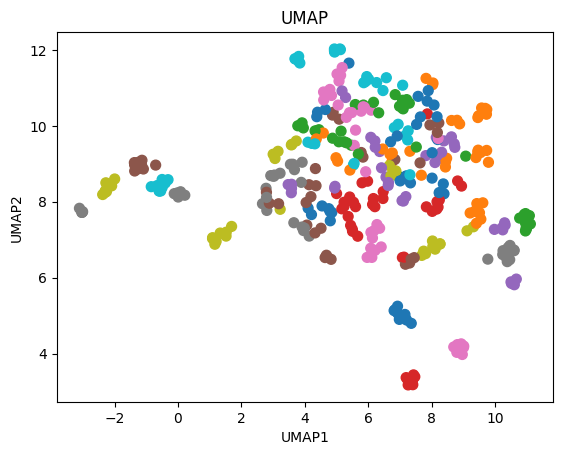

In [36]:
# Faces
model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(X_pca_face)
plt.scatter(umap[:, 0], umap[:, 1], c = y_f.astype(int), cmap = 'tab10', s = 50)
plt.title('UMAP')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

UMAP(min_dist=0.25, verbose=True)
Wed Jun 25 07:20:28 2025 Construct embedding


c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\umap\spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
Epochs completed:   8%| ▊          38/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs


Epochs completed:  31%| ███        153/500 [00:00]

	completed  100  /  500 epochs
	completed  150  /  500 epochs


...

	completed  300  /  500 epochs
	completed  350  /  500 epochs


Epochs completed:  91%| █████████  453/500 [00:01]

	completed  400  /  500 epochs
	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:01]


Wed Jun 25 07:20:30 2025 Finished embedding


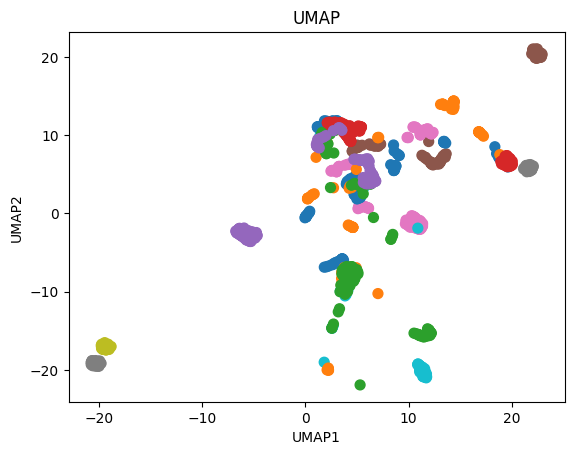

In [43]:
# COIL-20
model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(X_pca_coil)
plt.scatter(umap[:, 0], umap[:, 1], c = y_c.astype(int), cmap = 'tab10', s = 50)
plt.title('UMAP')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

UMAP(min_dist=0.25, verbose=True)
Tue Jun 24 16:21:08 2025 Construct fuzzy simplicial set
Tue Jun 24 16:21:10 2025 Finding Nearest Neighbors
Tue Jun 24 16:21:10 2025 Finished Nearest Neighbor Search
Tue Jun 24 16:21:10 2025 Construct embedding


Epochs completed:  26%| ██▌        129/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs


Epochs completed:  75%| ███████▌   375/500 [00:00]

	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed 

Epochs completed: 100%| ██████████ 500/500 [00:00]


 450  /  500 epochs
Tue Jun 24 16:21:11 2025 Finished embedding


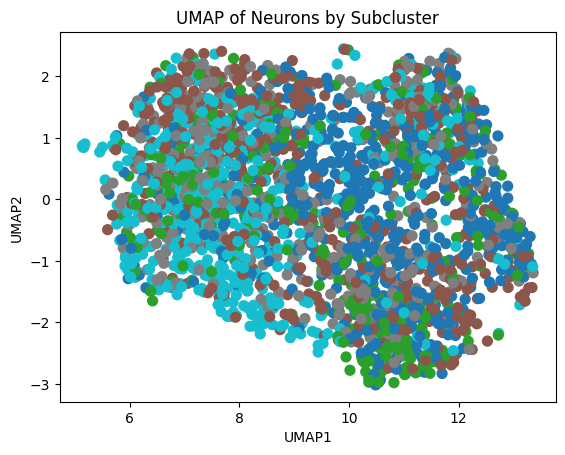

In [32]:
# Neurons
from UMAP.umap_ import UMAP


model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(X_pca_brain)
plt.scatter(umap[:, 0], umap[:, 1], c = y_b.astype(int), cmap = 'tab10', s = 50)
plt.title('UMAP of Neurons by Subcluster')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

# Additional bio data

In [61]:
import scanpy as sc

adata = sc.read_loom("Data/L5_All.agg.loom")

X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X

# Extract all columns starting with "Tissue_"
tissue_cols = [col for col in adata.obs.columns if col.startswith("Tissue_")]
# For each row, find which tissue column has a 1
adata.obs['TissueLabel'] = adata.obs[tissue_cols].idxmax(axis=1)

# Step 2: Normalize and PCA
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=40).fit_transform(X_scaled)

c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\anndata\_io\read.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  axis_df[k] = v
c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\anndata\_io\read.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  axis_df[k] = v
c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\anndata\_io\read.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

C:\Users\wpbro\AppData\Local\Temp\ipykernel_89216\2552409310.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs['TissueLabel'] = adata.obs[tissue_cols].idxmax(axis=1)


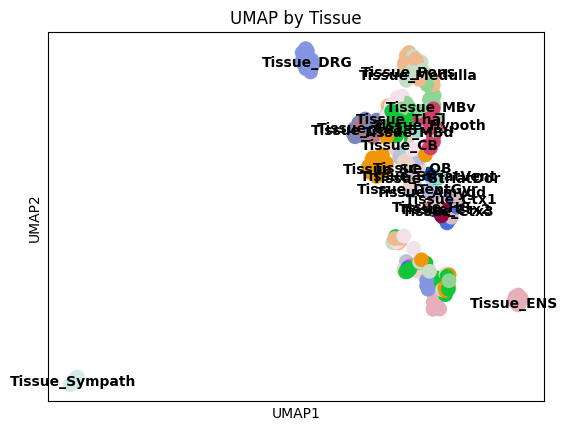

In [57]:
# Extract all columns starting with "Tissue_"
tissue_cols = [col for col in adata.obs.columns if col.startswith("Tissue_")]
# For each row, find which tissue column has a 1
adata.obs['TissueLabel'] = adata.obs[tissue_cols].idxmax(axis=1)
sc.pl.umap(adata, color='TissueLabel', legend_loc='on data', title='UMAP by Tissue')


UMAP(min_dist=0.25, verbose=True)
Wed Jun 25 09:01:23 2025 Construct fuzzy simplicial set
Wed Jun 25 09:01:23 2025 Finding Nearest Neighbors
Wed Jun 25 09:01:23 2025 Finished Nearest Neighbor Search
Wed Jun 25 09:01:23 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:00]
C:\Users\wpbro\AppData\Local\Temp\ipykernel_89216\2881548067.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20")(np.linspace(0, 1, len(tissue_names)))


	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Jun 25 09:01:23 2025 Finished embedding


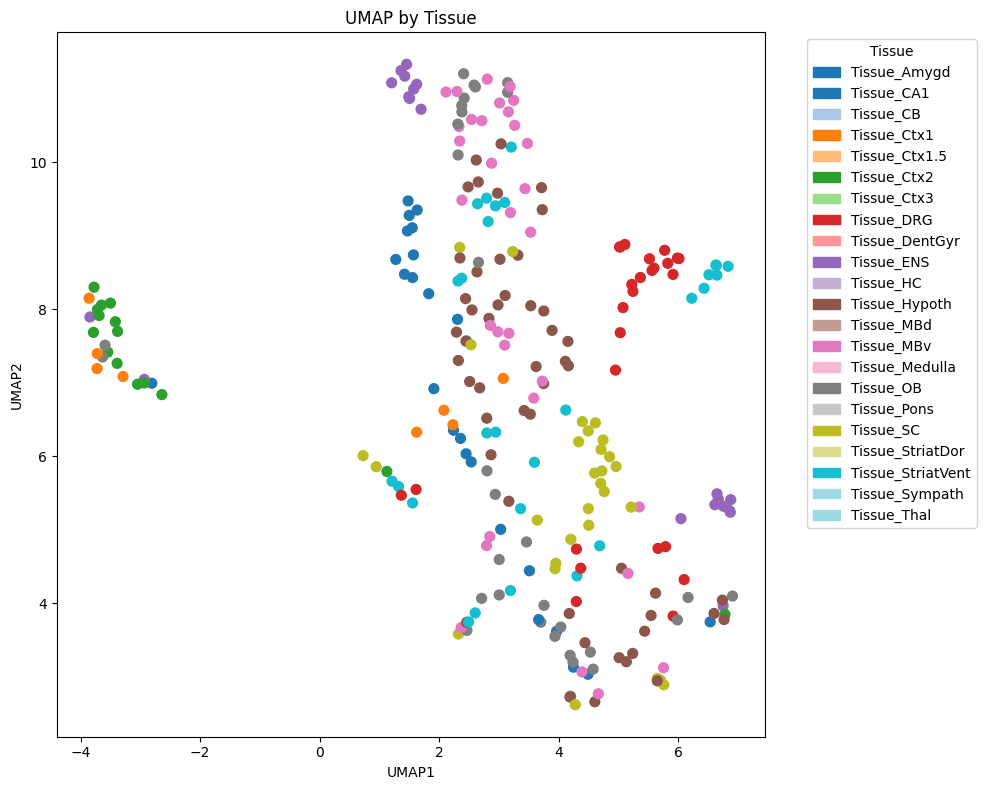

In [65]:
from UMAP.umap_ import UMAP
from sklearn.preprocessing import LabelEncoder
import matplotlib.patches as mpatches

model = UMAP(n_neighbors=15, min_dist=0.25, n_components=2, verbose=True)
umap = model.fit_transform(X_pca)

# Convert tissue labels to integers
le = LabelEncoder()
y_c = le.fit_transform(adata.obs['TissueLabel'])

# Plot
# Map tissue names to colors
np.random.seed(12)  # for reproducibility

tissue_names = np.sort(le.classes_)
colors = plt.cm.get_cmap("tab20")(np.linspace(0, 1, len(tissue_names)))

# Build a legend manually
legend_elements = [mpatches.Patch(color=colors[i], label=tissue_names[i])
                   for i in range(len(tissue_names))]

plt.figure(figsize=(10, 8))
plt.scatter(umap[:, 0], umap[:, 1], c=y_c, cmap='tab10', s=50)
plt.title("UMAP by Tissue")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(handles=legend_elements, title="Tissue", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

UMAP(min_dist=0.25, verbose=True)
Wed Jun 25 09:16:56 2025 Construct fuzzy simplicial set
Wed Jun 25 09:16:56 2025 Finding Nearest Neighbors
Wed Jun 25 09:16:56 2025 Finished Nearest Neighbor Search
Wed Jun 25 09:16:56 2025 Construct embedding


Epochs completed:  66%| ██████▌    331/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:00]


	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Jun 25 09:16:56 2025 Finished embedding


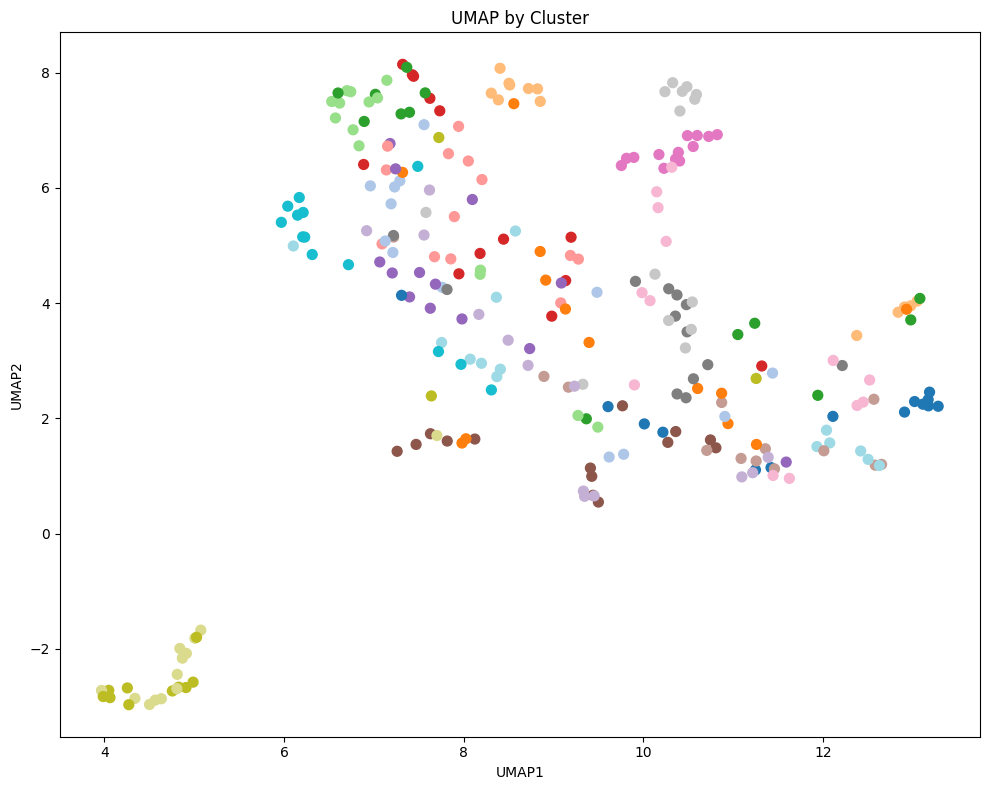

In [77]:
model = UMAP(n_neighbors=15, min_dist=0.25, n_components=2, verbose=True)
umap = model.fit_transform(X_pca)

# Step 2: Encode cluster names to integers
le = LabelEncoder()
y_c = le.fit_transform(adata.obs['ClusterName'])

# Step 3: Map cluster names to colors
cluster_names = le.classes_
colors = plt.cm.tab20(np.linspace(0, 1, len(cluster_names)))

# Step 5: Plot
plt.figure(figsize=(10, 8))
plt.scatter(umap[:, 0], umap[:, 1], c=y_c, cmap='tab20', s=50)
plt.title("UMAP by Cluster")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()

# Preprocessing function

In [4]:
def perturb_images(X: np.ndarray, num_invert: int, seed: int = None) -> np.ndarray:
    """
    Applies pixel swaps between neighboring pixels in a batch of images.

    Parameters:
    - X (np.ndarray): Input images of shape (n_samples, height, width)
    - num_invert (int): Number of pixel swaps per image
    - seed (int, optional): Random seed for reproducibility

    Returns:
    - np.ndarray: Perturbed images of the same shape
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    directions = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}
    perturbed_images = X.copy()
    h, w = X.shape[1], X.shape[2]

    for ii in range(len(X)):
        img = perturbed_images[ii]
        for _ in range(num_invert):
            n = np.random.randint(1, h - 1)
            m = np.random.randint(1, w - 1)
            dir_key = random.choice(list(directions.keys()))
            dn, dm = directions[dir_key]
            jn, jm = n + dn, m + dm

            # Swap pixel values
            img[n, m], img[jn, jm] = img[jn, jm], img[n, m]

    return perturbed_images


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train_perturbed = perturb_images(x_train[:500], num_invert=500, seed=12)

x_train_perturbed = x_train_perturbed[:500]
y_train = y_train[:500]

x_train_perturbed_flat = x_train_perturbed.reshape((x_train_perturbed.shape[0], -1)).astype(np.float32)

scaler = StandardScaler()
x_train_perturbed_scaled = scaler.fit_transform(x_train_perturbed_flat)

pca = PCA(n_components=40)
x_train_perturbed_pca = pca.fit_transform(x_train_perturbed_scaled)

UMAP(min_dist=0.25, verbose=True)
Mon Jul 21 15:25:34 2025 Construct fuzzy simplicial set
Mon Jul 21 15:25:34 2025 Finding Nearest Neighbors
Mon Jul 21 15:25:34 2025 Finished Nearest Neighbor Search
Mon Jul 21 15:25:34 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:00]


	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Jul 21 15:25:35 2025 Finished embedding


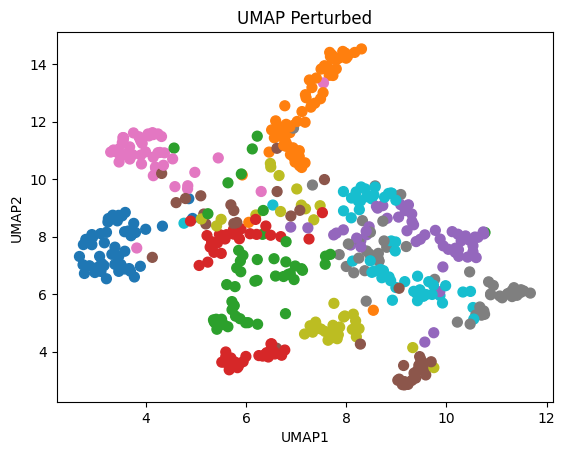

In [14]:
from UMAP.umap_ import UMAP

model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)
umap = model.fit_transform(x_train_perturbed_pca)
plt.scatter(umap[:, 0], umap[:, 1], c = y_train.astype(int), cmap = 'tab10', s = 50)
plt.title('UMAP Perturbed')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

# total scratch

Mon Jul 21 15:34:03 2025 Finding nearest neighbors
Mon Jul 21 15:34:03 2025 Finding Nearest Neighbors
Mon Jul 21 15:34:03 2025 Building RP forest with 12 trees
Mon Jul 21 15:34:03 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Mon Jul 21 15:34:04 2025 Finished Nearest Neighbor Search
Mon Jul 21 15:34:04 2025 Computing fuzzy simplicial set
Mon Jul 21 15:34:14 2025 Initializing embedding


  0%|          | 5/1000 [00:00<00:31, 31.14it/s]

	completed  0  /  1000 epochs


 10%|█         | 104/1000 [00:06<01:02, 14.28it/s]

	completed  100  /  1000 epochs


...

 80%|████████  | 805/1000 [00:43<00:10, 18.94it/s]

	completed  800  /  1000 epochs


 91%|█████████ | 906/1000 [00:48<00:05, 18.71it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:53<00:00, 18.87it/s]


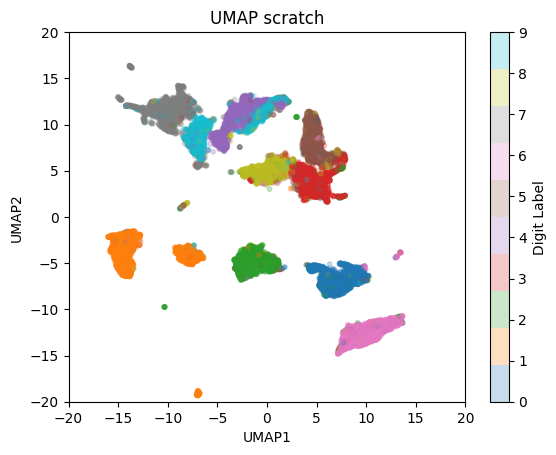

In [20]:
# Using the new UMAP function

from UMAP.umap_scratch import UMAP_scratch

model = UMAP_scratch(
    n_neighbors=15,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True
)
umap = model.fit_transform(x_train_pca)
scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP scratch')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.show()

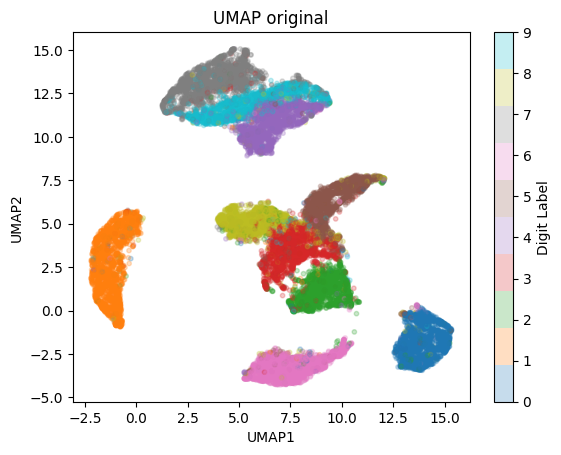

In [9]:
import umap
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
embedding = umap_model.fit_transform(x_train_pca)
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=y_train.astype(int), cmap='tab10', s=10, alpha =.25)
plt.title('UMAP original')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.show()

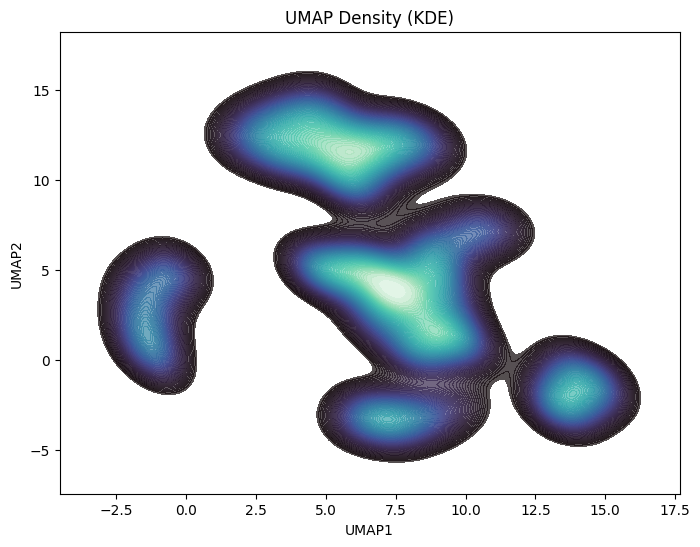

In [ ]:
plt.figure(figsize=(8, 6))
sns.kdeplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    fill=True,
    cmap="mako",
    thresh=0.05,
    levels=100,
    alpha=0.7
)
plt.title('UMAP Density (KDE)')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

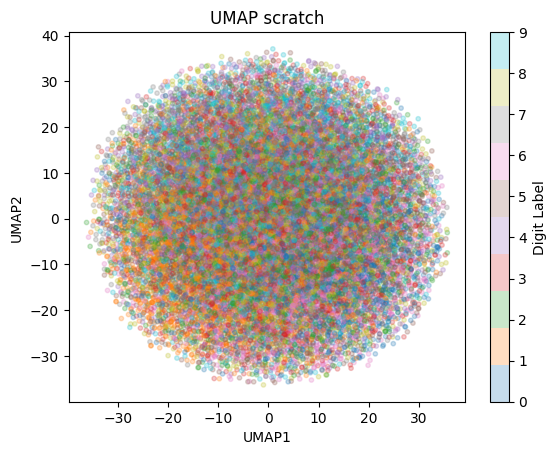

In [4]:

scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP scratch')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.show()

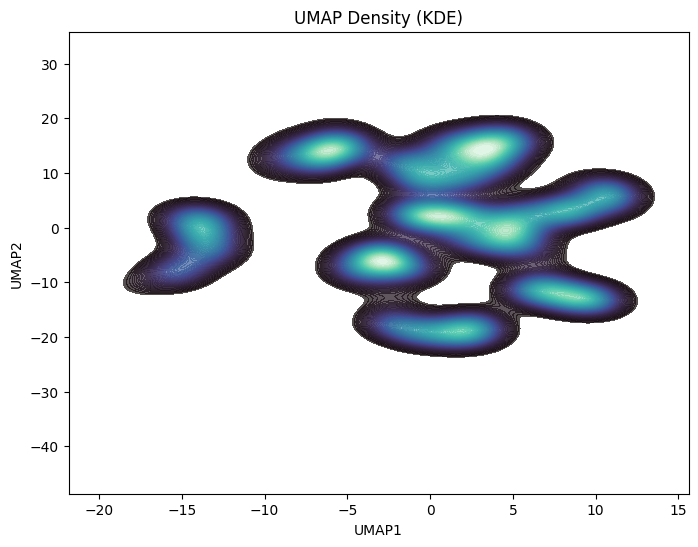

In [4]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.kdeplot(
    x=umap[:, 0],
    y=umap[:, 1],
    fill=True,
    cmap="mako",
    thresh=0.05,
    levels=100,
    alpha=0.7
)
plt.title('UMAP Density (KDE)')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()


## New p_ij (hopefully)


Mon Jul 21 16:15:11 2025 Finding nearest neighbors
Mon Jul 21 16:15:11 2025 Finding Nearest Neighbors
Mon Jul 21 16:15:11 2025 Building RP forest with 12 trees
Mon Jul 21 16:15:11 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Mon Jul 21 16:15:11 2025 Finished Nearest Neighbor Search
Mon Jul 21 16:15:11 2025 Computing fuzzy simplicial set
Mon Jul 21 16:15:34 2025 Initializing embedding


  1%|          | 10/1000 [00:00<00:38, 25.76it/s]

	completed  0  /  1000 epochs


 10%|█         | 104/1000 [00:05<00:52, 17.00it/s]

	completed  100  /  1000 epochs


...

 80%|████████  | 804/1000 [00:57<00:14, 13.43it/s]

	completed  800  /  1000 epochs


 90%|█████████ | 902/1000 [01:05<00:07, 12.92it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [01:13<00:00, 13.67it/s]


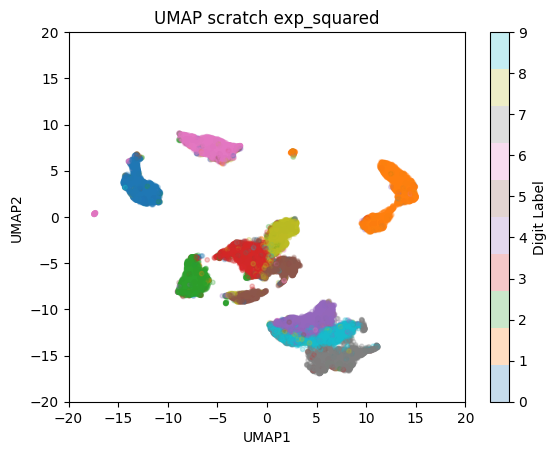

In [25]:
from UMAP.umap_scratch import UMAP_scratch

model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity='exp'
)
umap = model.fit_transform(x_train_pca)
scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP scratch exp_squared')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.show()

Mon Jul 21 15:57:27 2025 Finding nearest neighbors
Mon Jul 21 15:57:27 2025 Finding Nearest Neighbors
Mon Jul 21 15:57:27 2025 Building RP forest with 12 trees
Mon Jul 21 15:57:27 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Mon Jul 21 15:57:28 2025 Finished Nearest Neighbor Search
Mon Jul 21 15:57:28 2025 Computing fuzzy simplicial set
Mon Jul 21 15:57:47 2025 Initializing embedding


  0%|          | 4/1000 [00:00<00:43, 22.78it/s]

	completed  0  /  1000 epochs


 10%|█         | 103/1000 [00:12<01:50,  8.13it/s]

	completed  100  /  1000 epochs


...

 80%|████████  | 802/1000 [01:38<00:24,  8.19it/s]

	completed  800  /  1000 epochs


 90%|█████████ | 902/1000 [01:50<00:12,  8.11it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [02:02<00:00,  8.16it/s]


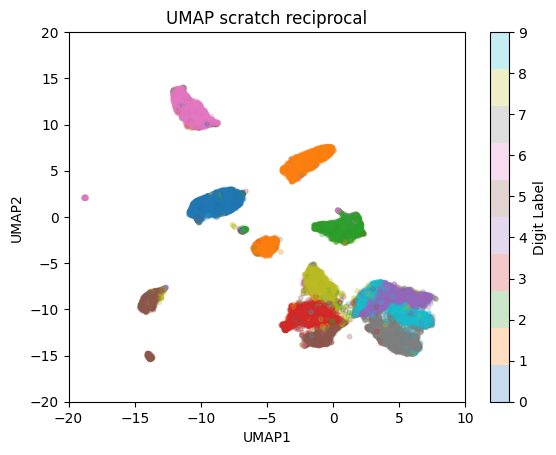

In [24]:
from UMAP.umap_scratch import UMAP_scratch

model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity='reciprocal'
)
umap = model.fit_transform(x_train_pca)
scatter = plt.scatter(umap[:, 0], umap[:, 1], c=y_train.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP scratch reciprocal')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.xlim(-20, 10)
plt.ylim(-20, 20)
plt.show()

# Perturbing function

In [59]:
def perturb_images(X: np.ndarray, num_invert: int, num_aug: int = 9, seed: int = None) -> np.ndarray:
    """
    Applies pixel swaps between neighboring pixels for each image,
    returning original + perturbed copies in proper label alignment.

    Parameters:
    - X (np.ndarray): Input images of shape (n_samples, height, width)
    - num_invert (int): Number of pixel swaps per image
    - num_aug (int): Number of augmentations per image
    - seed (int, optional): Random seed for reproducibility

    Returns:
    - np.ndarray: Augmented images of shape (n_samples * (1 + num_aug), height, width)
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    directions = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}
    h, w = X.shape[1], X.shape[2]
    originals = []
    perturbed = []

    for i in range(len(X)):
        base_img = X[i]
        originals.append(base_img)

        for _ in range(num_aug):
            img = np.copy(base_img)
            for _ in range(num_invert):
                n = np.random.randint(1, h - 1)
                m = np.random.randint(1, w - 1)
                dir_key = random.choice(list(directions.keys()))
                dn, dm = directions[dir_key]
                jn, jm = n + dn, m + dm

                # Swap pixel values
                img[n, m], img[jn, jm] = img[jn, jm], img[n, m]

            perturbed.append(img)

    return np.stack(originals + perturbed)

In [60]:
import random
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reduce to 100 samples
x_train = x_train[:1000]
y_train = y_train[:1000]

# Augment images: 9 perturbed versions per original
x_train_perturbed = perturb_images(x_train, num_invert=500, num_aug=9, seed=12)

# Repeat labels for new images
y_train_perturbed = np.tile(y_train, 10)

# Flatten
x_train_perturbed_flat = x_train_perturbed.reshape((x_train_perturbed.shape[0], -1)).astype(np.float32)

# Standardize
scaler = StandardScaler()
x_train_perturbed_scaled = scaler.fit_transform(x_train_perturbed_flat)

# PCA to 40 dimensions
pca = PCA(n_components=40)
x_train_perturbed_pca = pca.fit_transform(x_train_perturbed_scaled)

Tue Jul 15 14:46:15 2025 Finding nearest neighbors
Tue Jul 15 14:46:15 2025 Finding Nearest Neighbors
Tue Jul 15 14:46:15 2025 Building RP forest with 10 trees
Tue Jul 15 14:46:15 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Tue Jul 15 14:46:15 2025 Finished Nearest Neighbor Search
Tue Jul 15 14:46:15 2025 Computing fuzzy simplicial set
Tue Jul 15 14:46:23 2025 Initializing embedding


  1%|          | 12/1000 [00:00<00:21, 46.61it/s]

	completed  0  /  1000 epochs


 11%|█         | 110/1000 [00:02<00:22, 39.60it/s]

	completed  100  /  1000 epochs


...

 81%|████████  | 809/1000 [00:20<00:04, 39.36it/s]

	completed  800  /  1000 epochs


 91%|█████████ | 910/1000 [00:23<00:02, 39.82it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:25<00:00, 39.35it/s]


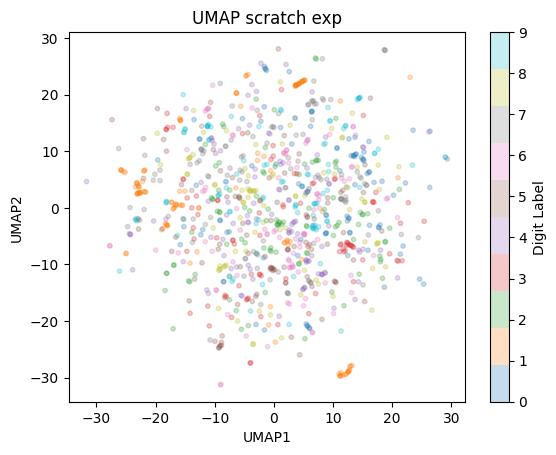

In [61]:
from UMAP.umap_scratch import UMAP_scratch

model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity='exp'
)
umap = model.fit_transform(x_train_perturbed_pca)
scatter = plt.scatter(umap[:1000, 0], umap[:1000, 1], c=y_train.astype(int), cmap='tab10', s=10, alpha = .25)
plt.title('UMAP scratch exp')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
plt.show()

## y = x Line

In [22]:
# Step 1: Generate a line y = x
n_points = 100
x = np.linspace(-10, 10, n_points)
y = x.copy()
data_line = np.vstack([x, y]).T

# Step 2: Standardize
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_line)

# Step 3: PCA to 40 dimensions (even if original is 2D)
# (This just satisfies your model input expectations, you can skip if unnecessary)
pca = PCA(n_components=2)  # use 2 to preserve structure
data_pca = pca.fit_transform(data_scaled)

Tue Jul 15 14:21:19 2025 Finding nearest neighbors
Tue Jul 15 14:21:19 2025 Finding Nearest Neighbors
Tue Jul 15 14:21:19 2025 Building RP forest with 5 trees
Tue Jul 15 14:21:19 2025 NN descent for 7 iterations
	 1  /  7
	 2  /  7
	Stopping threshold met -- exiting after 2 iterations
Tue Jul 15 14:21:19 2025 Finished Nearest Neighbor Search
Tue Jul 15 14:21:19 2025 Computing fuzzy simplicial set


c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\UMAP\umap_scratch.py:611: RuntimeWarning: overflow encountered in cast
  epochs_per_sample = make_epochs_per_sample(graph_data, self.n_epochs).astype(np.float32)


Tue Jul 15 14:21:19 2025 Initializing embedding


100%|██████████| 500/500 [00:00<00:00, 4126.71it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs


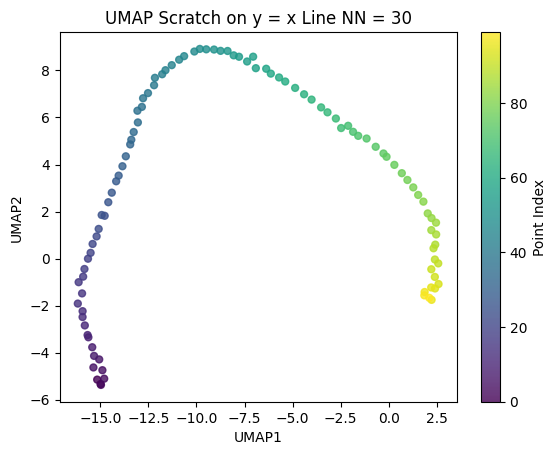

In [49]:
model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=500,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity='exp_squared'
)

umap_embedding = model.fit_transform(data_pca)

# Step 5: Plot the embedding
scatter = plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1],
                      c=np.arange(n_points), cmap='viridis', s=25, alpha=0.8)
plt.title('UMAP Scratch on y = x Line NN = 30')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Point Index')
plt.show()

# Generalized Perturbing Function

## MNIST

In [50]:
def perturb_image(X: np.ndarray, num_invert: int, num_aug: int = 9, seed: int = None) -> np.ndarray:
    """
    Applies pixel swaps between neighboring pixels.
    Returns original images followed by their augmentations,
    grouped per sample: [x0, x0_aug1, ..., x0_aug9, x1, x1_aug1, ..., x1_aug9, ...]
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    directions = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}

    if X.ndim == 3:
        n_samples, h, w = X.shape
        channels = None
    elif X.ndim == 4:
        n_samples, h, w, channels = X.shape
    else:
        raise ValueError("Input images must have shape (n_samples, H, W) or (n_samples, H, W, C)")

    all_outputs = []

    for i in range(n_samples):
        base_img = X[i]
        group = [np.copy(base_img)]

        for _ in range(num_aug):
            img = np.copy(base_img)
            for _ in range(num_invert):
                n = np.random.randint(1, h - 1)
                m = np.random.randint(1, w - 1)
                dn, dm = random.choice(list(directions.values()))
                jn, jm = n + dn, m + dm

                if channels is None:
                    img[n, m], img[jn, jm] = img[jn, jm], img[n, m]
                else:
                    img[n, m, :], img[jn, jm, :] = img[jn, jm, :], img[n, m, :]

            group.append(img)

        all_outputs.extend(group)

    return np.stack(all_outputs)


In [111]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reduce to 1000 samples
x_train = x_train[:1000]
y_train = y_train[:1000]

# Augment images: 9 perturbed versions per original
x_train_perturbed = perturb_image(x_train, num_invert=250, num_aug=9, seed=12)

# Repeat labels for new images
y_train_perturbed = np.tile(y_train, 10)

# Flatten
x_train_perturbed_flat = x_train_perturbed.reshape((x_train_perturbed.shape[0], -1)).astype(np.float32)

# Standardize
scaler = StandardScaler()
x_train_perturbed_scaled = scaler.fit_transform(x_train_perturbed_flat)

# PCA to 40 dimensions
pca = PCA(n_components=40)
x_train_perturbed_pca = pca.fit_transform(x_train_perturbed_scaled)


Wed Jul 16 14:04:39 2025 Finding nearest neighbors
Wed Jul 16 14:04:39 2025 Finding Nearest Neighbors
Wed Jul 16 14:04:39 2025 Building RP forest with 10 trees
Wed Jul 16 14:04:39 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Wed Jul 16 14:04:52 2025 Finished Nearest Neighbor Search
Wed Jul 16 14:04:52 2025 Computing fuzzy simplicial set
Wed Jul 16 14:07:18 2025 Initializing embedding


  0%|          | 4/2000 [00:00<01:14, 26.66it/s]

	completed  0  /  2000 epochs


 10%|█         | 204/2000 [00:14<02:13, 13.44it/s]

	completed  200  /  2000 epochs


...

 80%|████████  | 1603/2000 [02:08<00:30, 12.89it/s]

	completed  1600  /  2000 epochs


 90%|█████████ | 1803/2000 [02:24<00:15, 12.97it/s]

	completed  1800  /  2000 epochs


100%|██████████| 2000/2000 [02:40<00:00, 12.45it/s]


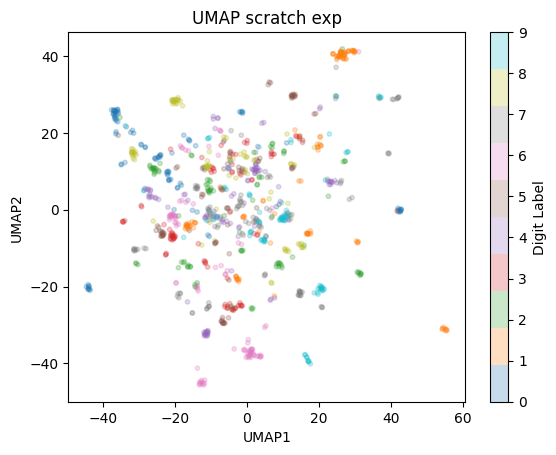

In [114]:
from UMAP.umap_scratch import UMAP_scratch

model = UMAP_scratch(
    n_neighbors=300,
    n_components=2,
    metric="euclidean",
    n_epochs=2000,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.001,
    spread=2.0,
    random_state=42,
    verbose=True,
    similarity='exp'
)
umap = model.fit_transform(x_train_perturbed_pca)
orig_idxs = np.arange(0, umap.shape[0], 10)
Y_orig = umap[orig_idxs]
scatter = plt.scatter(Y_orig[:, 0], Y_orig[:, 1], c=y_train, cmap='tab10', s=10, alpha = .25)
plt.title('UMAP scratch exp')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(scatter, label='Digit Label')
#plt.xlim(-20, 20)
#plt.ylim(-20, 20)
plt.show()

Wed Jul 16 09:22:07 2025 Finding nearest neighbors
Wed Jul 16 09:22:07 2025 Finding Nearest Neighbors
Wed Jul 16 09:22:07 2025 Building RP forest with 7 trees
Wed Jul 16 09:22:07 2025 NN descent for 10 iterations
	 1  /  10
	 2  /  10
	 3  /  10
	Stopping threshold met -- exiting after 3 iterations
Wed Jul 16 09:22:07 2025 Finished Nearest Neighbor Search
Wed Jul 16 09:22:07 2025 Computing fuzzy simplicial set
Wed Jul 16 09:22:08 2025 Initializing embedding


  4%|▍         | 40/1000 [00:00<00:02, 390.89it/s]

	completed  0  /  1000 epochs


 15%|█▌        | 153/1000 [00:00<00:02, 350.83it/s]

	completed  100  /  1000 epochs


...

 85%|████████▌ | 853/1000 [00:02<00:00, 340.13it/s]

	completed  800  /  1000 epochs


 96%|█████████▌| 958/1000 [00:02<00:00, 340.98it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:02<00:00, 342.58it/s]


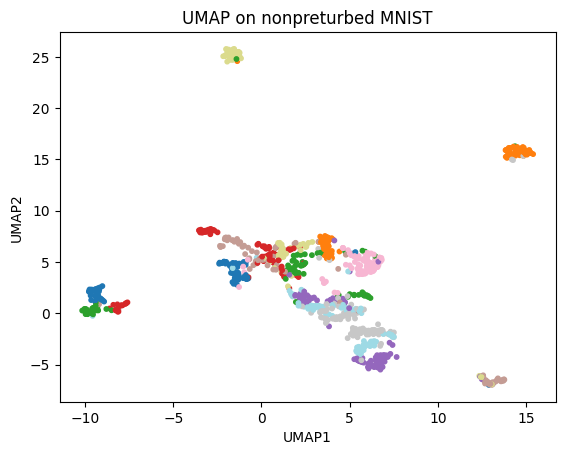

In [108]:
from UMAP.umap_scratch import UMAP_scratch

x_train_flat = x_train.reshape((x_train.shape[0], -1)).astype(np.float32)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
pca = PCA(n_components=40)
x_train_pca = pca.fit_transform(x_train_scaled)

model = model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="spectral",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity="exp",
)
umap = model.fit_transform(x_train_pca)
plt.scatter(umap[:, 0], umap[:, 1], c = y_train, cmap = 'tab20', s = 10)
plt.title('UMAP on nonpreturbed MNIST')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

## Faces

In [93]:
from sklearn.datasets import fetch_olivetti_faces

# Load Olivetti Faces
faces = fetch_olivetti_faces(shuffle=False, random_state=1)
X_face = faces.data
y_face = faces.target.copy()

# Sample 5 images per class (40 classes → 200 total images)
samples_per_class = 5
unique_classes = np.unique(y_face)  # this should give [0, 1, ..., 39]

X_balanced = []
y_balanced_grouped = []

for cls in unique_classes:
    idx = np.where(y_face == cls)[0]
    chosen = np.random.choice(idx, samples_per_class, replace=False)
    
    for i in range(samples_per_class):
        X_balanced.append(X_face[chosen[i]])
        y_balanced_grouped.append(cls)

X_balanced = np.array(X_balanced)
y_balanced_grouped = np.array(y_balanced_grouped)

X_face_reshaped = X_balanced.reshape(-1, 64, 64)
X_face_perturbed = perturb_image(X_face_reshaped, num_invert=500, num_aug=9, seed=42)
y_face_perturbed = np.repeat(y_balanced_grouped, 10)

# Flatten and apply PCA
X_face_flat = X_face_perturbed.reshape(X_face_perturbed.shape[0], -1)
X_face_scaled = StandardScaler().fit_transform(X_face_flat)
X_face_pca = PCA(n_components=40).fit_transform(X_face_scaled)

Wed Jul 16 08:54:05 2025 Finding nearest neighbors
Wed Jul 16 08:54:05 2025 Finding Nearest Neighbors
Wed Jul 16 08:54:05 2025 Building RP forest with 7 trees
Wed Jul 16 08:54:05 2025 NN descent for 11 iterations
	 1  /  11
	 2  /  11
	 3  /  11
	 4  /  11
	 5  /  11
	 6  /  11
	Stopping threshold met -- exiting after 6 iterations
Wed Jul 16 08:54:05 2025 Finished Nearest Neighbor Search
Wed Jul 16 08:54:05 2025 Computing fuzzy simplicial set


c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\UMAP\umap_scratch.py:611: RuntimeWarning: overflow encountered in cast
  epochs_per_sample = make_epochs_per_sample(graph_data, self.n_epochs).astype(np.float32)


Wed Jul 16 08:54:07 2025 Initializing embedding


  2%|▏         | 24/1000 [00:00<00:04, 239.42it/s]

	completed  0  /  1000 epochs


...

 84%|████████▎ | 837/1000 [00:03<00:00, 223.42it/s]

	completed  800  /  1000 epochs


 93%|█████████▎| 930/1000 [00:04<00:00, 227.00it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:04<00:00, 225.33it/s]


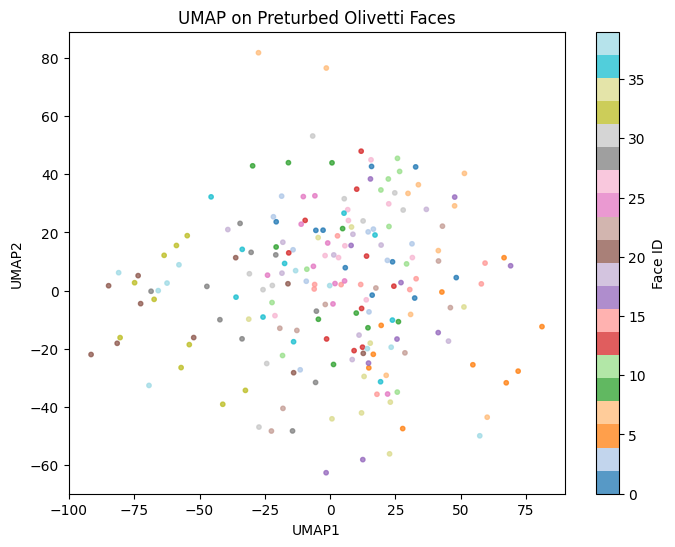

In [101]:
from UMAP.umap_scratch import UMAP_scratch


model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="pca",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity="exp",
)
Y = model.fit_transform(X_face_pca)

orig_idxs = np.arange(0, Y.shape[0], 10)
Y_orig   = Y[orig_idxs]
y_orig   = y_face_perturbed[orig_idxs]

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(Y_orig[:,0], Y_orig[:,1], c=y_orig, cmap='tab20', s=10, alpha=0.75)
plt.colorbar(scatter, label="Face ID")
plt.title("UMAP on Preturbed Olivetti Faces")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()


Wed Jul 16 08:42:10 2025 Finding nearest neighbors
Wed Jul 16 08:42:10 2025 Finding Nearest Neighbors
Wed Jul 16 08:42:10 2025 Building RP forest with 6 trees
Wed Jul 16 08:42:10 2025 NN descent for 8 iterations
	 1  /  8
	 2  /  8
	 3  /  8
	Stopping threshold met -- exiting after 3 iterations
Wed Jul 16 08:42:10 2025 Finished Nearest Neighbor Search
Wed Jul 16 08:42:10 2025 Computing fuzzy simplicial set
Wed Jul 16 08:42:10 2025 Initializing embedding


 18%|█▊        | 175/1000 [00:00<00:00, 1739.53it/s]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs


 52%|█████▏    | 517/1000 [00:00<00:00, 1643.49it/s]

	completed  400  /  1000 epochs
	completed  500  /  1000 epochs


 68%|██████▊   | 682/1000 [00:00<00:00, 1642.38it/s]

	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs


 85%|████████▍ | 847/1000 [00:00<00:00, 1627.13it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:00<00:00, 1649.58it/s]


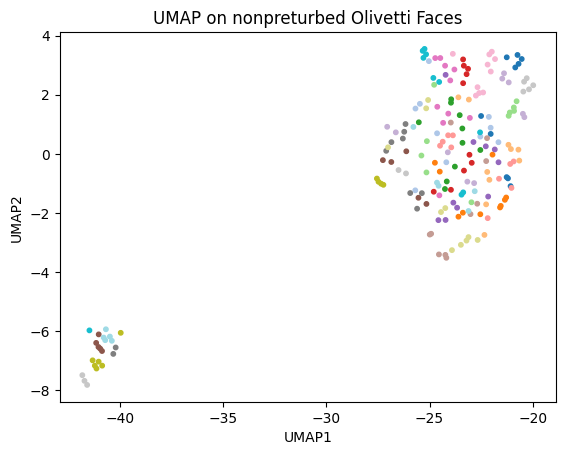

In [100]:
from UMAP.umap_scratch import UMAP_scratch

X_flat_face = X_balanced.reshape(X_face_reshaped.shape[0], -1)
X_scaled_face = StandardScaler().fit_transform(X_flat_face)
X_pca_face = PCA(n_components=40).fit_transform(X_scaled_face)

# Faces
model = model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="pca",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity="exp",
)
umap = model.fit_transform(X_pca_face)
plt.scatter(umap[:, 0], umap[:, 1], c = y_balanced_grouped[:200], cmap = 'tab20', s = 10)
plt.title('UMAP on nonpreturbed Olivetti Faces')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

## COIL-20

In [103]:
from sklearn.utils import shuffle

# Load COIL-20 (assumes grayscale .png images like obj1_1.png)
path = r'C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\coil-20-proc\coil-20-proc'

X_coil = []
y_coil = []

for file in sorted(os.listdir(path)):
    if file.endswith(".png"):
        label = int(file.split("_")[0].replace("obj", ""))
        img = Image.open(os.path.join(path, file)).convert("L").resize((32, 32))
        X_coil.append(np.array(img))
        y_coil.append(label)

X_coil = np.array(X_coil)
y_coil = np.array(y_coil)

X_coil, y_coil = shuffle(X_coil, y_coil, random_state=42)
X_coil = X_coil[:500]
y_coil = y_coil[:500]

# Apply perturbation (e.g., 300 swaps per image, 0 augmentations)
X_coil_perturbed = perturb_image(X_coil, num_invert=300, num_aug=9, seed=24)

y_coil_perturbed = np.repeat(y_coil, 10)

# Flatten and normalize
X_coil_flat = X_coil_perturbed.reshape(X_coil_perturbed.shape[0], -1)

scaler_coil = StandardScaler()
X_coil_scaled = scaler_coil.fit_transform(X_coil_flat)

pca_coil = PCA(n_components=40)
X_coil_pca = pca_coil.fit_transform(X_coil_scaled)


Wed Jul 16 08:55:55 2025 Finding nearest neighbors
Wed Jul 16 08:55:55 2025 Finding Nearest Neighbors
Wed Jul 16 08:55:55 2025 Building RP forest with 9 trees
Wed Jul 16 08:55:55 2025 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	 4  /  12
	Stopping threshold met -- exiting after 4 iterations
Wed Jul 16 08:55:55 2025 Finished Nearest Neighbor Search
Wed Jul 16 08:55:55 2025 Computing fuzzy simplicial set


c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\UMAP\umap_scratch.py:611: RuntimeWarning: overflow encountered in cast
  epochs_per_sample = make_epochs_per_sample(graph_data, self.n_epochs).astype(np.float32)


Wed Jul 16 08:56:00 2025 Initializing embedding


  1%|          | 10/1000 [00:00<00:10, 93.59it/s]

	completed  0  /  1000 epochs


...

 81%|████████  | 812/1000 [00:10<00:02, 78.71it/s]

	completed  800  /  1000 epochs


 91%|█████████ | 909/1000 [00:11<00:01, 79.22it/s]

	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:12<00:00, 78.44it/s]


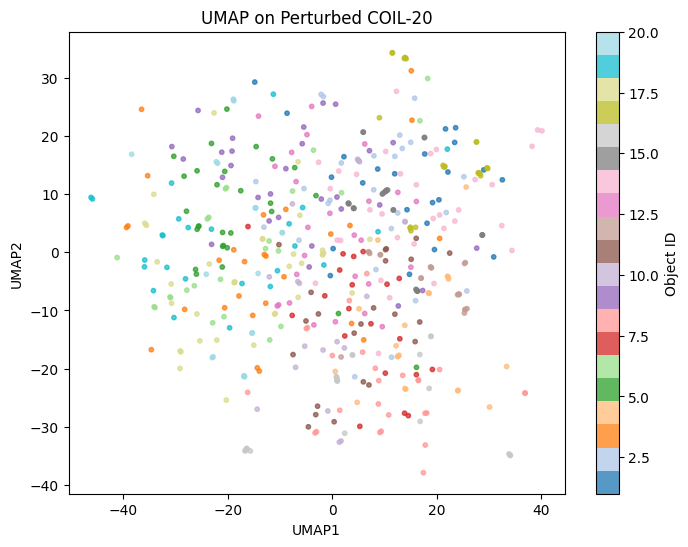

In [104]:
from UMAP.umap_scratch import UMAP_scratch

model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="pca",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity="exp",
)
Y_coil = model.fit_transform(X_coil_pca)


orig_idxs_coil = np.arange(0, Y_coil.shape[0], 10)
Y_coil_orig = Y_coil[orig_idxs_coil]
y_coil_orig = y_coil_perturbed[orig_idxs_coil]

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(Y_coil_orig[:,0], Y_coil_orig[:,1], c=y_coil_orig, cmap='tab20', s=10, alpha=0.75)
plt.colorbar(scatter, label="Object ID")
plt.title("UMAP on Perturbed COIL-20")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()


Tue Jul 15 15:42:06 2025 Finding nearest neighbors
Tue Jul 15 15:42:06 2025 Finding Nearest Neighbors
Tue Jul 15 15:42:06 2025 Building RP forest with 6 trees
Tue Jul 15 15:42:06 2025 NN descent for 9 iterations
	 1  /  9
	 2  /  9
	 3  /  9
	Stopping threshold met -- exiting after 3 iterations
Tue Jul 15 15:42:06 2025 Finished Nearest Neighbor Search
Tue Jul 15 15:42:06 2025 Computing fuzzy simplicial set
Tue Jul 15 15:42:07 2025 Initializing embedding


  7%|▋         | 73/1000 [00:00<00:02, 361.35it/s]

	completed  0  /  1000 epochs


 19%|█▉        | 188/1000 [00:00<00:01, 503.73it/s]

	completed  100  /  1000 epochs
	completed  200  /  1000 epochs


...

 68%|██████▊   | 685/1000 [00:01<00:00, 503.37it/s]

	completed  600  /  1000 epochs
	completed  700  /  1000 epochs


 88%|████████▊ | 878/1000 [00:01<00:00, 427.92it/s]

	completed  800  /  1000 epochs
	completed  900  /  1000 epochs


100%|██████████| 1000/1000 [00:02<00:00, 475.30it/s]


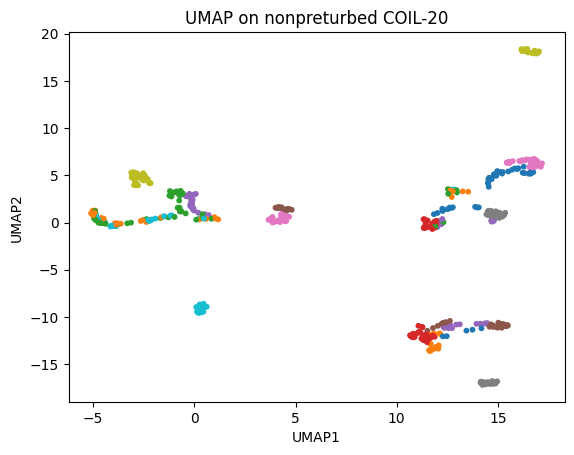

In [97]:
from UMAP.umap_scratch import UMAP_scratch

X_flat_coil = X_coil.reshape(X_coil.shape[0], -1)

coil_scaler = StandardScaler()
X_scaled_coil = coil_scaler.fit_transform(X_flat_coil)

X_coil_pca = PCA(n_components=40)
X_pca_coil = X_coil_pca.fit_transform(X_scaled_coil)

model = UMAP_scratch(
    n_neighbors=30,
    n_components=2,
    metric="euclidean",
    n_epochs=1000,
    learning_rate=1.0,
    init="pca",
    min_dist=0.1,
    spread=1.0,
    random_state=42,
    verbose=True,
    similarity="exp",
)
umap = model.fit_transform(X_pca_coil)
plt.scatter(umap[:, 0], umap[:, 1], c = y_coil.astype(int), cmap = 'tab10', s = 10)
plt.title('UMAP on nonpreturbed COIL-20')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()